# Week 1 — Day 2: Flickr8k Data Exploration

Tasks:
- Explore Flickr8k: number of images, captions per image, caption length distribution, vocabulary size
- Visual inspection: display sample images with their captions
- Identify data quality issues (duplicate captions, blank/short captions, corrupted images)

Deliverable: exploration notebook with statistics tables/plots (caption length histogram, vocab size, sample image-caption grid).

### 1. Load captions into a DataFrame

In [1]:
import os
import cv2
import nltk
import string
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
from tqdm import tqdm

nltk.download('punkt', quiet=True)

captions_path = '../data/captions.txt'
img_dir = '../data/Images'

df = pd.read_csv(captions_path)
df.columns = ['image', 'caption']
print(f"Total captions: {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
print(f"Captions per image (should be ~5):")
print(df.groupby('image').size().value_counts())
df.head()

Total captions: 40455


Unique images: 8091
Captions per image (should be ~5):


5    8091
Name: count, dtype: int64


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


### 2. Caption length distribution

count    40455.000000
mean        11.782969
std          3.885309
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: n_words, dtype: float64


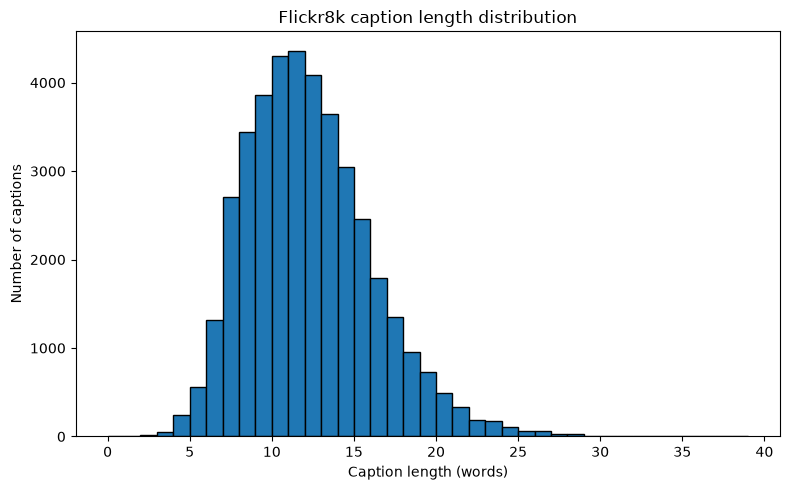

In [2]:
df['n_words'] = df['caption'].astype(str).apply(lambda c: len(nltk.word_tokenize(c)))

print(df['n_words'].describe())

plt.figure(figsize=(8, 5))
plt.hist(df['n_words'], bins=range(0, df['n_words'].max() + 2), edgecolor='black')
plt.xlabel('Caption length (words)')
plt.ylabel('Number of captions')
plt.title('Flickr8k caption length distribution')
plt.tight_layout()
plt.savefig('../data/processed/caption_length_hist.png', dpi=120)
plt.show()

### 3. Vocabulary size (raw captions, lowercase + punctuation stripped)

In [3]:
vocab = Counter()
for caption in tqdm(df['caption'].astype(str)):
    tokens = nltk.word_tokenize(caption.lower())
    tokens = [t for t in tokens if t not in string.punctuation]
    vocab.update(tokens)

print(f"Vocabulary size (raw, no stop-word removal): {len(vocab)}")
print("Most common words:")
for word, count in vocab.most_common(15):
    print(f"  {word:15s} {count}")

  0%|          | 0/40455 [00:00<?, ?it/s]

  2%|▏         | 687/40455 [00:00<00:05, 6867.81it/s]

  4%|▍         | 1541/40455 [00:00<00:04, 7837.59it/s]

  6%|▋         | 2551/40455 [00:00<00:04, 8293.71it/s]

  9%|▊         | 3504/40455 [00:00<00:04, 8698.04it/s]

...

 93%|█████████▎| 37758/40455 [00:04<00:00, 9323.01it/s]

 96%|█████████▌| 38690/40455 [00:04<00:00, 8859.56it/s]

 98%|█████████▊| 39579/40455 [00:04<00:00, 8493.37it/s]

100%|██████████| 40455/40455 [00:04<00:00, 8894.33it/s]

Vocabulary size (raw, no stop-word removal): 8904
Most common words:
  a               62986
  in              18974
  the             18418
  on              10743
  is              9345
  and             8851
  dog             8136
  with            7765
  man             7265
  of              6713
  two             5638
  white           3940
  black           3832
  boy             3581
  are             3504


Note: this raw vocabulary count (punctuation-stripped, stop words kept) is expected to be
larger than the cleaned vocabulary from the Day 4 preprocessing notebook (8,788 tokens),
since Day 4 additionally removes English stop words.

### 4. Visual inspection — sample image/caption grid

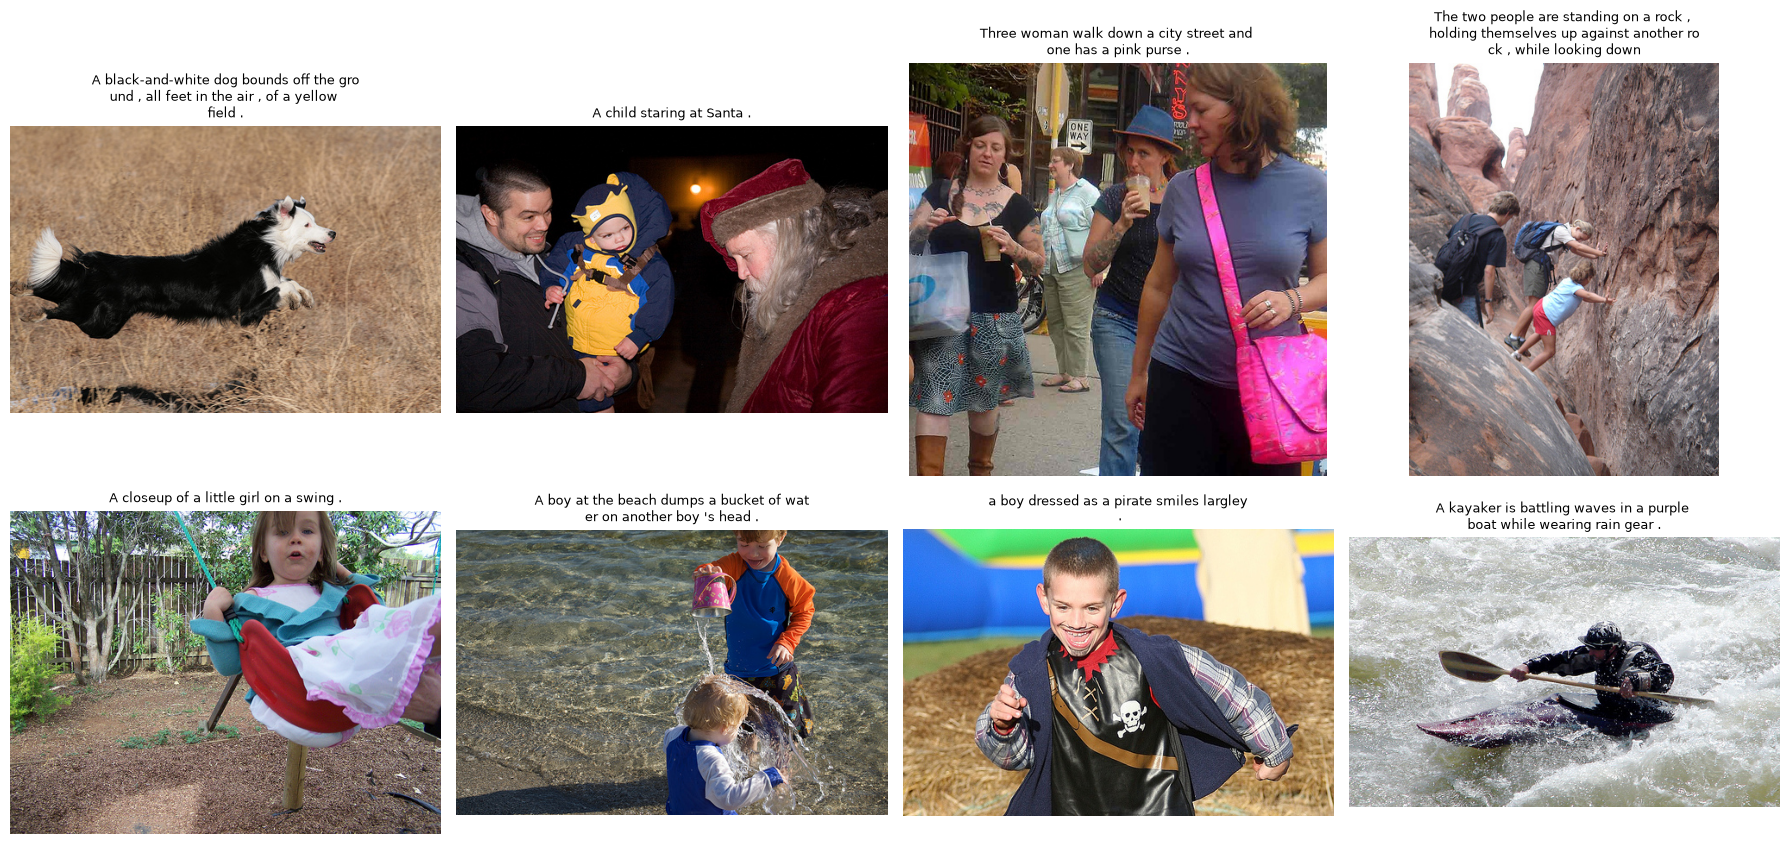

In [4]:
sample_images = df['image'].drop_duplicates().sample(8, random_state=42).tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, img_name in zip(axes.flat, sample_images):
    img = Image.open(os.path.join(img_dir, img_name)).convert('RGB')
    caption = df[df['image'] == img_name]['caption'].iloc[0]
    ax.imshow(img)
    ax.set_title('\n'.join([caption[i:i+40] for i in range(0, len(caption), 40)]), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('../data/processed/sample_image_caption_grid.png', dpi=120)
plt.show()

### 5. Data quality — duplicate and blank/short captions

In [5]:
# Exact duplicate captions (same image, same caption text)
dupes = df[df.duplicated(subset=['image', 'caption'], keep=False)]
print(f"Exact duplicate (image, caption) rows: {len(dupes)}")

# Blank or very short captions (fewer than 3 words)
short_captions = df[df['n_words'] < 3]
print(f"Captions with fewer than 3 words: {len(short_captions)}")
short_captions.head(10)

Exact duplicate (image, caption) rows: 20
Captions with fewer than 3 words: 17


,image,caption,n_words
5585,2165461920_1a4144eb2b.jpg,dogs racing,2
9305,2428275562_4bde2bc5ea.jpg,A,1
9593,244760301_5809214866.jpg,People walking,2
11363,256085101_2c2617c5d0.jpg,Dog yawns,2
13730,2714703706_d21c5cb8df.jpg,dogs playing,2
14298,2755314937_1e974bf2b5.jpg,broken image,2
15784,2862481071_86c65d46fa.jpg,Trucks racing,2
17104,2929669711_b2d5a640f0.jpg,man surfing,2
20322,3108732084_565b423162.jpg,a snowboarder,2
20672,3125309108_1011486589.jpg,rugby match,2


### 6. Data quality — corrupted / unreadable images

In [6]:
all_images = df['image'].drop_duplicates().tolist()
corrupted = []

for img_name in tqdm(all_images):
    img_path = os.path.join(img_dir, img_name)
    if not os.path.exists(img_path):
        corrupted.append((img_name, 'missing file'))
        continue
    img = cv2.imread(img_path)
    if img is None:
        corrupted.append((img_name, 'unreadable by OpenCV'))
        continue
    if img.ndim != 3 or img.shape[2] != 3:
        corrupted.append((img_name, f'unexpected shape {img.shape}'))

print(f"Corrupted/problematic images: {len(corrupted)} out of {len(all_images)}")
corrupted[:10]

  0%|          | 0/8091 [00:00<?, ?it/s]

  0%|          | 6/8091 [00:00<02:15, 59.77it/s]

  0%|          | 13/8091 [00:00<02:02, 65.76it/s]

  0%|          | 20/8091 [00:00<02:03, 65.31it/s]

  0%|          | 27/8091 [00:00<02:19, 57.80it/s]

...

 99%|█████████▉| 8049/8091 [01:01<00:00, 273.21it/s]

100%|█████████▉| 8077/8091 [01:01<00:00, 274.68it/s]

100%|██████████| 8091/8091 [01:01<00:00, 130.58it/s]

Corrupted/problematic images: 0 out of 8091


[]

### Summary

- Dataset size and captions-per-image: see section 1 above
- Caption length: see histogram in section 2; most captions fall in a narrow word-count band, with a few outliers at each tail
- Vocabulary: raw (punctuation-stripped) vocab size is reported in section 3; it drops to 8,788 tokens after stop-word removal (Day 4 preprocessing)
- Data quality: duplicate-caption and short-caption counts are reported in section 5; the corrupted-image scan result is in section 6 (0 expected, since Day 4 preprocessing already read and transformed all 8,091 images without error)